# Co-Information Estimator Bias Diagnosis & SPONGE Failure Mechanism Analysis

Two-part diagnostic experiment:
- **Part 1**: Compare CoI estimation methods (NPEET KSG, raw KSG, binning, sklearn KSG) on synthetic datasets with planted synergy modules to determine whether universally negative CoI values are a KSG bias artifact or genuine.
- **Part 2**: Diagnose why SPONGE signed spectral clustering underperforms unsigned spectral on all-negative CoI graphs via eigenspectrum, condition number, and positive edge injection analysis.

Key findings: binning shows 100% negative CoI on XOR-only datasets; SPONGE fails catastrophically (ARI=-0.5) while unsigned spectral achieves ARI=1.0; eigenspectrum confirms L_pos degeneration.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# npeet — NOT on Colab, always install (only available via git)
_pip('git+https://github.com/gregversteeg/NPEET.git')

# Core packages — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    # Colab versions: numpy==2.0.2, scipy==1.16.3, scikit-learn==1.6.1, matplotlib==3.10.0
    # Use compatible versions for local Python (scipy 1.16+ needs Python 3.11+)
    _v = sys.version_info
    if _v >= (3, 11):
        _pip('numpy==2.0.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')
    else:
        _pip('numpy==2.0.2', 'scipy==1.15.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import time
import warnings

import numpy as np
from scipy.linalg import eigh, eigvalsh
from scipy.special import digamma
from sklearn.cluster import KMeans
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import adjusted_rand_score, mutual_info_score
from sklearn.neighbors import KDTree, NearestNeighbors
import npeet.entropy_estimators as ee
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7dffcf-balance-guided-oblique-trees-signed-spec/main/experiment_iter4_co_information/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded precomputed results: {list(data.keys())}")
print(f"Part 1 datasets: {list(data['part1_estimator_bias'].keys())}")
print(f"Part 2 datasets: {list(data['part2_sponge_diagnosis'].keys())}")

Loaded precomputed results: ['metadata', 'part1_estimator_bias', 'part2_sponge_diagnosis', 'conclusions', 'datasets']
Part 1 datasets: ['calibration_pure_xor', 'easy_2mod_xor', 'medium_4mod_mixed', 'no_structure_control']
Part 2 datasets: ['easy_2mod_xor', 'medium_4mod_mixed']


In [5]:
# ---- Configuration (tunable parameters) ----
# Near-original values. Full pipeline runs in <30s.
# Original full-run values are commented for reference.

N_CAL_SAMPLES = 15000     # Original: 50000
N_EASY_SAMPLES = 10000    # Original: 10000
K_NEIGHBORS = 5           # Original: 5
MAX_KSG_SAMPLES = 10000   # Original: 10000-15000
N_BINS_LIST = [10, 20, 50]  # Original: [10, 20, 50]
SEED = 42

## Synthetic Data Generation

Generate two datasets with planted synergistic feature modules:
1. **Calibration Pure XOR** (5 features): Clean XOR(X0,X1)=Y with known analytical CoI = -ln(2)
2. **Easy 2-Module XOR** (10 features): Two XOR modules [0,1] and [2,3] with redundant copies and noise features

In [6]:
def make_redundant(x, sigma, rng):
    """Create redundant feature: x + N(0, sigma^2)."""
    return x + rng.normal(0, sigma, size=x.shape)

def xor_interaction(x1, x2):
    """XOR: sign(x1 * x2). Zero marginal MI with target."""
    return np.sign(x1 * x2)

def generate_target(contributions, weights, sigma_noise, rng):
    """Generate binary target from weighted module contributions."""
    n = contributions[0].shape[0]
    logit = np.zeros(n)
    for c, w in zip(contributions, weights):
        logit += w * (c - c.mean())
    logit += rng.normal(0, sigma_noise, size=n)
    return (logit > 0).astype(int)

# --- Generate calibration_pure_xor ---
rng99 = np.random.default_rng(99)
X_cal = rng99.standard_normal((N_CAL_SAMPLES, 5))
X_cal[:, 3] = X_cal[:, 0] + np.random.default_rng(100).normal(0, 0.3, N_CAL_SAMPLES)
Y_cal = (X_cal[:, 0] * X_cal[:, 1] > 0).astype(int)
meta_cal = {
    "n_samples": N_CAL_SAMPLES, "n_features": 5, "n_modules": 1,
    "ground_truth_modules": [[0, 1]],
    "module_types": ["xor"],
    "redundant_pairs": [[0, 3]],
    "noise_features": [4],
    "feature_names": [f"X{i}" for i in range(5)],
}

# --- Generate easy_2mod_xor ---
rng_easy = np.random.default_rng(SEED)
X_easy = rng_easy.standard_normal((N_EASY_SAMPLES, 10))
c_a = xor_interaction(X_easy[:, 0], X_easy[:, 1])
c_b = xor_interaction(X_easy[:, 2], X_easy[:, 3])
X_easy[:, 4] = make_redundant(X_easy[:, 0], 0.3, rng_easy)
X_easy[:, 5] = make_redundant(X_easy[:, 2], 0.3, rng_easy)
Y_easy = generate_target([c_a, c_b], [1.0, 1.0], 0.1, rng_easy)
meta_easy = {
    "n_samples": N_EASY_SAMPLES, "n_features": 10, "n_modules": 2,
    "ground_truth_modules": [[0, 1], [2, 3]],
    "module_types": ["xor", "xor"],
    "redundant_pairs": [[0, 4], [2, 5]],
    "noise_features": [6, 7, 8, 9],
    "feature_names": [f"X{i}" for i in range(10)],
}

datasets = {
    "calibration_pure_xor": {"X": X_cal, "y": Y_cal, "meta": meta_cal},
    "easy_2mod_xor": {"X": X_easy, "y": Y_easy, "meta": meta_easy},
}

for name, ds in datasets.items():
    print(f"  {name}: X={ds['X'].shape}, balance={ds['y'].mean():.3f}")

  calibration_pure_xor: X=(15000, 5), balance=0.488
  easy_2mod_xor: X=(10000, 10), balance=0.488


## MI Estimation Methods & CoI Matrix Computation

Define multiple mutual information estimators:
- **NPEET KSG** (abs-clipped): Standard KSG estimator via NPEET library
- **Raw NPEET** (no abs): Exposes raw KSG estimate which can be negative
- **Binned MI**: Discretization-based MI at configurable resolution
- **sklearn KSG**: sklearn's `mutual_info_classif` for individual MI

Co-Information (CoI) for each pair (i,j): `CoI(i,j) = MI(Xi;Y) + MI(Xj;Y) - MI(Xi,Xj;Y)`
- Negative CoI = synergy (features jointly informative)
- Positive CoI = redundancy (features share information)

In [7]:
# ---------------------------------------------------------------------------
# MI Estimation Methods
# ---------------------------------------------------------------------------

def npeet_mi_cd(X_nd, y, k=5):
    """Compute MI(X;Y) using NPEET's micd. X continuous, Y discrete.
    NPEET uses abs() internally so result is always >= 0."""
    if X_nd.ndim == 1:
        X_nd = X_nd.reshape(-1, 1)
    y_2d = y.reshape(-1, 1) if y.ndim == 1 else y
    try:
        mi = ee.micd(X_nd, y_2d, k=k, base=np.e, warning=False)
        return float(mi)
    except Exception as e:
        print(f"NPEET micd failed: {e}")
        return 0.0


def raw_npeet_mi_cd(X_nd, y, k=5):
    """Compute MI(X;Y) using NPEET entropy internals WITHOUT abs() clipping.
    This exposes the raw KSG estimate, which can be negative."""
    if X_nd.ndim == 1:
        X_nd = X_nd.reshape(-1, 1)
    y_2d = y.reshape(-1, 1) if y.ndim == 1 else y
    try:
        entropy_x = ee.entropy(X_nd, k=k, base=np.e)
        y_unique, y_count = np.unique(y_2d, return_counts=True, axis=0)
        y_proba = y_count / len(y_2d)
        entropy_x_given_y = 0.0
        for yval, py in zip(y_unique, y_proba):
            mask = (y_2d == yval).all(axis=1)
            x_given_y = X_nd[mask]
            if k <= len(x_given_y) - 1:
                entropy_x_given_y += py * ee.entropy(x_given_y, k=k, base=np.e)
            else:
                entropy_x_given_y += py * entropy_x
        return float(entropy_x - entropy_x_given_y)  # RAW, no abs()
    except Exception as e:
        print(f"raw NPEET MI failed: {e}")
        return 0.0


def binned_mi(x_binned, y):
    """MI between discrete binned feature and discrete target (nats)."""
    return float(mutual_info_score(x_binned, y))


def bin_feature(x, n_bins):
    """Bin a continuous feature into n_bins discrete bins."""
    edges = np.linspace(x.min() - 1e-10, x.max() + 1e-10, n_bins + 1)
    return np.clip(np.digitize(x, edges[1:-1]), 0, n_bins - 1)


# ---------------------------------------------------------------------------
# CoI Matrix computation (serial — no ProcessPoolExecutor for notebook)
# ---------------------------------------------------------------------------

def compute_coi_npeet(X, y, k=5, max_samples=None):
    """Compute CoI matrix using NPEET KSG (abs-clipped individual MI)."""
    n, d = X.shape
    if max_samples and n > max_samples:
        rng = np.random.default_rng(42)
        idx = rng.choice(n, max_samples, replace=False)
        X, y = X[idx], y[idx]

    mi_ind = np.array([npeet_mi_cd(X[:, i], y, k=k) for i in range(d)])

    mi_jnt = np.zeros((d, d))
    for i in range(d):
        for j in range(i + 1, d):
            X_2d = np.column_stack([X[:, i], X[:, j]])
            mi_jnt[i, j] = mi_jnt[j, i] = npeet_mi_cd(X_2d, y, k=k)

    coi = np.zeros((d, d))
    for i in range(d):
        for j in range(i + 1, d):
            coi[i, j] = coi[j, i] = mi_ind[i] + mi_ind[j] - mi_jnt[i, j]
    return coi, mi_ind, mi_jnt


def compute_coi_raw_npeet(X, y, k=5, max_samples=None):
    """Compute CoI using raw NPEET (no abs clipping) -- diagnostic method."""
    n, d = X.shape
    if max_samples and n > max_samples:
        rng = np.random.default_rng(42)
        idx = rng.choice(n, max_samples, replace=False)
        X, y = X[idx], y[idx]

    mi_ind = np.array([raw_npeet_mi_cd(X[:, i], y, k=k) for i in range(d)])

    mi_jnt = np.zeros((d, d))
    for i in range(d):
        for j in range(i + 1, d):
            X_2d = np.column_stack([X[:, i], X[:, j]])
            mi_jnt[i, j] = mi_jnt[j, i] = raw_npeet_mi_cd(X_2d, y, k=k)

    coi = np.zeros((d, d))
    for i in range(d):
        for j in range(i + 1, d):
            coi[i, j] = coi[j, i] = mi_ind[i] + mi_ind[j] - mi_jnt[i, j]
    return coi, mi_ind, mi_jnt


def compute_coi_binned(X, y, n_bins=20):
    """Compute CoI matrix using discretization-based MI."""
    n, d = X.shape
    X_binned = np.zeros((n, d), dtype=int)
    for i in range(d):
        X_binned[:, i] = bin_feature(X[:, i], n_bins)

    mi_ind = np.array([binned_mi(X_binned[:, i], y) for i in range(d)])

    mi_jnt = np.zeros((d, d))
    for i in range(d):
        for j in range(i + 1, d):
            combined = X_binned[:, i] * n_bins + X_binned[:, j]
            mi_jnt[i, j] = mi_jnt[j, i] = binned_mi(combined, y)

    coi = np.zeros((d, d))
    for i in range(d):
        for j in range(i + 1, d):
            coi[i, j] = coi[j, i] = mi_ind[i] + mi_ind[j] - mi_jnt[i, j]
    return coi, mi_ind, mi_jnt


def compute_coi_sklearn(X, y, k=5, max_samples=None):
    """Compute CoI with sklearn individual MI + NPEET joint MI."""
    n, d = X.shape
    if max_samples and n > max_samples:
        rng = np.random.default_rng(42)
        idx = rng.choice(n, max_samples, replace=False)
        X, y = X[idx], y[idx]

    mi_ind = mutual_info_classif(X, y, n_neighbors=k, random_state=42)

    mi_jnt = np.zeros((d, d))
    for i in range(d):
        for j in range(i + 1, d):
            X_2d = np.column_stack([X[:, i], X[:, j]])
            mi_jnt[i, j] = mi_jnt[j, i] = npeet_mi_cd(X_2d, y, k=k)

    coi = np.zeros((d, d))
    for i in range(d):
        for j in range(i + 1, d):
            coi[i, j] = coi[j, i] = mi_ind[i] + mi_ind[j] - mi_jnt[i, j]
    return coi, mi_ind, mi_jnt

print("MI estimation and CoI functions defined.")

MI estimation and CoI functions defined.


## Part 1: Run Estimator Bias Test

Compute CoI matrices using all estimation methods on the calibration dataset.
Compare sign distributions to determine whether negative CoI is genuine or an estimator artifact.

In [8]:
def analyze_coi_matrix(coi, meta, method_name):
    """Compute comprehensive statistics on a CoI matrix."""
    d = coi.shape[0]
    upper_idx = np.triu_indices(d, k=1)
    values = coi[upper_idx]
    n_pairs = len(values)
    if n_pairs == 0:
        return {"method": method_name, "error": "no pairs"}

    n_pos = int(np.sum(values > 0.001))
    n_neg = int(np.sum(values < -0.001))
    n_zero = int(np.sum(np.abs(values) <= 0.001))

    stats = {
        "method": method_name,
        "n_features": d, "n_pairs": n_pairs,
        "sign_distribution": {
            "n_positive": n_pos, "n_negative": n_neg, "n_near_zero": n_zero,
            "frac_positive": round(n_pos / n_pairs, 4),
            "frac_negative": round(n_neg / n_pairs, 4),
            "frac_near_zero": round(n_zero / n_pairs, 4),
        },
        "distribution_stats": {
            "mean": round(float(np.mean(values)), 6),
            "median": round(float(np.median(values)), 6),
            "std": round(float(np.std(values)), 6),
            "min": round(float(np.min(values)), 6),
            "max": round(float(np.max(values)), 6),
        },
    }

    # Known redundant pairs
    pairs_list = meta.get("redundant_pairs", [])
    entries = []
    for pair in pairs_list:
        i, j = pair
        if i < d and j < d:
            entries.append({
                "pair": pair,
                "coi_value": round(float(coi[i, j]), 6),
                "sign": "positive" if coi[i, j] > 0.001 else (
                    "negative" if coi[i, j] < -0.001 else "near_zero"),
            })
    stats["redundant_pair_coi"] = entries

    # Synergistic pairs from ground truth modules
    modules = meta.get("ground_truth_modules", [])
    mtype = meta.get("module_types", ["unknown"] * len(modules))
    syn_entries = []
    for m_idx, mod in enumerate(modules):
        for ii in range(len(mod)):
            for jj in range(ii + 1, len(mod)):
                fi, fj = mod[ii], mod[jj]
                if fi < d and fj < d:
                    syn_entries.append({
                        "pair": [fi, fj], "module": m_idx,
                        "module_type": mtype[m_idx] if m_idx < len(mtype) else "unknown",
                        "coi_value": round(float(coi[fi, fj]), 6),
                        "sign": "positive" if coi[fi, fj] > 0.001 else (
                            "negative" if coi[fi, fj] < -0.001 else "near_zero"),
                    })
    stats["synergistic_pair_coi"] = syn_entries
    return stats

# Run Part 1: compute CoI with all methods on calibration dataset
part1_results = {}
coi_store = {}

for ds_name in ["calibration_pure_xor", "easy_2mod_xor"]:
    ds = datasets[ds_name]
    X, y, meta = ds["X"], ds["y"], ds["meta"]
    d = X.shape[1]
    print(f"\n--- {ds_name} (n={X.shape[0]}, d={d}) ---")
    ds_res = {}

    # NPEET KSG (abs-clipped)
    t0 = time.time()
    print(f"  NPEET KSG (k={K_NEIGHBORS})...")
    coi_np, mi_np, mj_np = compute_coi_npeet(X, y, k=K_NEIGHBORS, max_samples=MAX_KSG_SAMPLES)
    print(f"  NPEET done in {time.time()-t0:.1f}s")
    ds_res["npeet_ksg"] = analyze_coi_matrix(coi_np, meta, "npeet_ksg")
    ds_res["npeet_ksg"]["mi_individual"] = [round(float(v), 6) for v in mi_np]

    # Raw NPEET (no abs -- diagnostic)
    t0 = time.time()
    print(f"  Raw NPEET KSG (no abs)...")
    coi_raw, mi_raw, mj_raw = compute_coi_raw_npeet(X, y, k=K_NEIGHBORS, max_samples=MAX_KSG_SAMPLES)
    print(f"  Raw NPEET done in {time.time()-t0:.1f}s")
    ds_res["raw_npeet_ksg"] = analyze_coi_matrix(coi_raw, meta, "raw_npeet_ksg")
    ds_res["raw_npeet_ksg"]["mi_individual"] = [round(float(v), 6) for v in mi_raw]
    ds_res["raw_npeet_ksg"]["n_negative_individual_mi"] = int(np.sum(mi_raw < 0))

    # Binning
    coi_bin = None
    for nb in N_BINS_LIST:
        t0 = time.time()
        print(f"  Binned({nb})...")
        coi_b, mi_b, mj_b = compute_coi_binned(X, y, n_bins=nb)
        print(f"  Binned({nb}) done in {time.time()-t0:.1f}s")
        key = f"binned_{nb}"
        ds_res[key] = analyze_coi_matrix(coi_b, meta, key)
        coi_bin = coi_b

    # sklearn KSG
    t0 = time.time()
    print(f"  sklearn KSG...")
    coi_sk, mi_sk, mj_sk = compute_coi_sklearn(X, y, k=K_NEIGHBORS, max_samples=MAX_KSG_SAMPLES)
    print(f"  sklearn done in {time.time()-t0:.1f}s")
    ds_res["sklearn_ksg"] = analyze_coi_matrix(coi_sk, meta, "sklearn_ksg")

    coi_store[ds_name] = {"npeet_ksg": coi_np, "binned": coi_bin}
    part1_results[ds_name] = ds_res

    # Print sign distribution summary
    for m in ds_res:
        sd = ds_res[m].get("sign_distribution", {})
        if sd:
            print(f"  {m}: frac_neg={sd.get('frac_negative','-')}, frac_pos={sd.get('frac_positive','-')}")


--- calibration_pure_xor (n=15000, d=5) ---
  NPEET KSG (k=5)...


  NPEET done in 0.3s
  Raw NPEET KSG (no abs)...


  Raw NPEET done in 0.3s
  Binned(10)...
  Binned(10) done in 0.0s
  Binned(20)...
  Binned(20) done in 0.0s
  Binned(50)...
  Binned(50) done in 0.0s
  sklearn KSG...


  sklearn done in 0.3s
  npeet_ksg: frac_neg=0.3, frac_pos=0.6
  raw_npeet_ksg: frac_neg=0.3, frac_pos=0.6
  binned_10: frac_neg=0.9, frac_pos=0.0
  binned_20: frac_neg=1.0, frac_pos=0.0
  binned_50: frac_neg=1.0, frac_pos=0.0
  sklearn_ksg: frac_neg=0.3, frac_pos=0.5

--- easy_2mod_xor (n=10000, d=10) ---
  NPEET KSG (k=5)...


  NPEET done in 1.3s
  Raw NPEET KSG (no abs)...


  Raw NPEET done in 1.3s
  Binned(10)...
  Binned(10) done in 0.0s
  Binned(20)...
  Binned(20) done in 0.0s
  Binned(50)...
  Binned(50) done in 0.0s
  sklearn KSG...


  sklearn done in 1.3s
  npeet_ksg: frac_neg=0.3778, frac_pos=0.4444
  raw_npeet_ksg: frac_neg=0.4222, frac_pos=0.4889
  binned_10: frac_neg=0.9556, frac_pos=0.0
  binned_20: frac_neg=1.0, frac_pos=0.0
  binned_50: frac_neg=1.0, frac_pos=0.0
  sklearn_ksg: frac_neg=0.6222, frac_pos=0.2889


## Part 2: Spectral Analysis & SPONGE Failure Diagnosis

Analyze why SPONGE signed spectral clustering fails on all-negative CoI graphs:
1. **Eigenspectrum analysis**: Examine Laplacian eigenvalues for L_pos, L_neg, L_abs, L_signed
2. **Clustering comparison**: Unsigned spectral vs SPONGE_sym
3. **Edge injection test**: Can artificial positive edges rescue SPONGE?

In [9]:
# ---------------------------------------------------------------------------
# Part 2: Spectral Analysis
# ---------------------------------------------------------------------------

def decompose_signed_graph(W):
    """Decompose signed adjacency into positive/negative components and Laplacians."""
    d = W.shape[0]
    W_clean = W.copy()
    np.fill_diagonal(W_clean, 0)

    A_pos = np.maximum(W_clean, 0)
    A_neg = np.maximum(-W_clean, 0)

    D_pos = np.diag(A_pos.sum(axis=1))
    D_neg = np.diag(A_neg.sum(axis=1))
    D_bar = np.diag(np.abs(W_clean).sum(axis=1))

    L_pos = D_pos - A_pos
    L_neg = D_neg - A_neg
    L_abs = D_bar - np.abs(W_clean)
    L_signed = D_bar - W_clean

    return {
        "A_pos": A_pos, "A_neg": A_neg,
        "D_pos": D_pos, "D_neg": D_neg, "D_bar": D_bar,
        "L_pos": L_pos, "L_neg": L_neg, "L_abs": L_abs, "L_signed": L_signed,
    }


def eigenspectrum_analysis(decomp):
    """Compute eigenspectra of all Laplacians."""
    results = {}
    for name in ["L_pos", "L_neg", "L_abs", "L_signed"]:
        evals = eigvalsh(decomp[name])
        results[name] = {
            "eigenvalues": [round(float(e), 8) for e in evals],
            "rank": int(np.sum(np.abs(evals) > 1e-10)),
            "min_eval": round(float(evals[0]), 8),
            "max_eval": round(float(evals[-1]), 8),
        }
    total_pos = float(decomp["A_pos"].sum()) / 2
    total_neg = float(decomp["A_neg"].sum()) / 2
    total_all = total_pos + total_neg
    results["positive_edge_fraction"] = round(total_pos / max(total_all, 1e-10), 6)
    results["negative_edge_fraction"] = round(total_neg / max(total_all, 1e-10), 6)
    return results


def frustration_index(decomp):
    """Spectral frustration: lambda_min / lambda_max of L_signed."""
    evals = eigvalsh(decomp["L_signed"])
    if abs(evals[-1]) < 1e-10:
        return 0.0
    return round(float(evals[0] / evals[-1]), 6)


def assign_ground_truth_labels(meta, d):
    labels = np.full(d, -1, dtype=int)
    for m_idx, mod in enumerate(meta.get("ground_truth_modules", [])):
        for f in mod:
            if f < d and labels[f] == -1:
                labels[f] = m_idx
    return labels


def unsigned_spectral_clustering(W, k):
    """Unsigned spectral clustering on |W| graph."""
    d = W.shape[0]
    W_abs = np.abs(W.copy())
    np.fill_diagonal(W_abs, 0)
    d_bar = W_abs.sum(axis=1)
    d_bar_safe = np.maximum(d_bar, 1e-10)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(d_bar_safe))
    L_abs = np.diag(d_bar) - W_abs
    L_norm = D_inv_sqrt @ L_abs @ D_inv_sqrt

    try:
        evals, evecs = eigh(L_norm, subset_by_index=[0, k - 1])
    except Exception:
        evals, evecs = eigh(L_norm)
        evecs = evecs[:, :k]

    norms = np.maximum(np.linalg.norm(evecs, axis=1, keepdims=True), 1e-10)
    V = evecs / norms
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return KMeans(n_clusters=k, n_init=20, random_state=42).fit_predict(V)


def sponge_sym_clustering(W, k, tau_p=1.0, tau_n=1.0, weight_by_evals=True):
    """SPONGE_sym clustering on signed graph W."""
    d = W.shape[0]
    decomp = decompose_signed_graph(W)

    d_pos = np.maximum(np.diag(decomp["D_pos"]), 1e-10)
    d_neg = np.maximum(np.diag(decomp["D_neg"]), 1e-10)
    Dp_isq = np.diag(1.0 / np.sqrt(d_pos))
    Dn_isq = np.diag(1.0 / np.sqrt(d_neg))

    L_sym_pos = Dp_isq @ decomp["L_pos"] @ Dp_isq
    L_sym_neg = Dn_isq @ decomp["L_neg"] @ Dn_isq

    A_mat = L_sym_pos + tau_n * np.eye(d)
    B_mat = L_sym_neg + tau_p * np.eye(d) + 1e-10 * np.eye(d)

    try:
        evals_sp, evecs_sp = eigh(A_mat, b=B_mat, subset_by_index=[0, k - 1])
    except Exception:
        try:
            L_chol = np.linalg.cholesky(B_mat)
            L_inv = np.linalg.inv(L_chol)
            std_mat = L_inv @ A_mat @ L_inv.T
            evals_sp, evecs_std = eigh(std_mat, subset_by_index=[0, k - 1])
            evecs_sp = L_inv.T @ evecs_std
        except Exception:
            print("SPONGE_sym eigendecomp failed")
            return np.zeros(d, dtype=int)

    if weight_by_evals:
        evecs_use = evecs_sp / np.maximum(np.abs(evals_sp), 1e-10)
    else:
        evecs_use = evecs_sp

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return KMeans(n_clusters=k, n_init=20, random_state=42).fit_predict(evecs_use)


def clustering_comparison(W, meta, dataset_name):
    """Compare unsigned spectral vs SPONGE_sym clustering."""
    d = W.shape[0]
    modules = meta.get("ground_truth_modules", [])
    if not modules:
        return {"dataset": dataset_name, "note": "no ground truth modules"}

    k_true = len(modules)
    gt = assign_ground_truth_labels(meta, d)
    mask = gt >= 0
    if mask.sum() < 2:
        return {"dataset": dataset_name, "note": "insufficient labeled features"}

    res = {"dataset": dataset_name, "k_true": k_true}
    for label, fn, kw in [
        ("unsigned_spectral_ari", unsigned_spectral_clustering, {}),
        ("sponge_sym_weighted_ari", sponge_sym_clustering, {"weight_by_evals": True}),
        ("sponge_sym_unweighted_ari", sponge_sym_clustering, {"weight_by_evals": False}),
    ]:
        try:
            pred = fn(W, k_true, **kw)
            res[label] = round(float(adjusted_rand_score(gt[mask], pred[mask])), 4)
        except Exception as e:
            print(f"{label} failed: {e}")
            res[label] = None
    return res


def edge_injection_test(W, meta, dataset_name):
    """Test whether artificial positive edge injection rescues SPONGE."""
    d = W.shape[0]
    modules = meta.get("ground_truth_modules", [])
    if not modules:
        return {"dataset": dataset_name, "note": "no modules"}

    k_true = len(modules)
    gt = assign_ground_truth_labels(meta, d)
    mask = gt >= 0
    if mask.sum() < 2:
        return {"dataset": dataset_name, "note": "insufficient labeled features"}

    upper = W[np.triu_indices(d, k=1)]
    results = {"dataset": dataset_name, "strategies": {}}
    strategies = {}

    # Strategy 1: Median thresholding
    W1 = W.copy()
    med = np.median(upper)
    above = W1 > med
    W1[above] = np.abs(W1[above])
    W1 = (W1 + W1.T) / 2
    np.fill_diagonal(W1, 0)
    strategies["median_thresholding"] = W1

    # Strategy 2: Percentile shift
    W2 = W - np.percentile(upper, 25)
    W2 = (W2 + W2.T) / 2
    np.fill_diagonal(W2, 0)
    strategies["percentile_shift"] = W2

    # Strategy 3: Known-structure injection
    W3 = W.copy()
    for pair in meta.get("redundant_pairs", []):
        i, j = pair
        if i < d and j < d:
            W3[i, j] = W3[j, i] = abs(W[i, j])
    strategies["known_structure_injection"] = W3

    for name, W_mod in strategies.items():
        try:
            n_pos = int(np.sum(W_mod[np.triu_indices(d, k=1)] > 0))
            pred = sponge_sym_clustering(W_mod, k_true)
            ari = float(adjusted_rand_score(gt[mask], pred[mask]))
            results["strategies"][name] = {
                "ari": round(ari, 4),
                "n_positive_edges": n_pos,
                "frac_positive": round(n_pos / max(len(upper), 1), 4),
            }
        except Exception as e:
            print(f"{name} failed: {e}")
            results["strategies"][name] = {"error": "failed"}
    return results

print("Spectral analysis and clustering functions defined.")

Spectral analysis and clustering functions defined.


In [10]:
# Run Part 2 on easy_2mod_xor using NPEET KSG CoI matrix
part2_results = {}
ds_name = "easy_2mod_xor"
meta = datasets[ds_name]["meta"]
W = coi_store[ds_name]["npeet_ksg"]
d = W.shape[0]
print(f"\n--- Part 2: {ds_name} (d={d}) ---")

res = {}
decomp = decompose_signed_graph(W)

print("  Eigenspectrum...")
res["eigenspectrum"] = eigenspectrum_analysis(decomp)
print(f"    Positive edge fraction: {res['eigenspectrum']['positive_edge_fraction']}")
print(f"    L_pos rank: {res['eigenspectrum']['L_pos']['rank']}")

print("  Frustration index...")
res["frustration_index"] = frustration_index(decomp)
print(f"    Frustration: {res['frustration_index']}")

print("  Clustering comparison...")
res["clustering_comparison"] = clustering_comparison(W, meta, ds_name)
for k, v in res["clustering_comparison"].items():
    if "ari" in k.lower():
        print(f"    {k}: {v}")

print("  Edge injection test...")
res["edge_injection"] = edge_injection_test(W, meta, ds_name)
for sname, sdata in res["edge_injection"].get("strategies", {}).items():
    if isinstance(sdata, dict) and "ari" in sdata:
        print(f"    {sname}: ARI={sdata['ari']}, frac_pos={sdata.get('frac_positive', '-')}")

# Also test with binned CoI
W_b = coi_store[ds_name].get("binned")
if W_b is not None:
    print("  Clustering on binned CoI...")
    res["clustering_binned"] = clustering_comparison(W_b, meta, f"{ds_name}_binned")
    for k, v in res["clustering_binned"].items():
        if "ari" in k.lower():
            print(f"    binned {k}: {v}")

part2_results[ds_name] = res
print("\nPart 2 complete.")


--- Part 2: easy_2mod_xor (d=10) ---
  Eigenspectrum...
    Positive edge fraction: 0.161189
    L_pos rank: 9
  Frustration index...
    Frustration: 0.039868
  Clustering comparison...


    unsigned_spectral_ari: 1.0
    sponge_sym_weighted_ari: -0.5
    sponge_sym_unweighted_ari: -0.5
  Edge injection test...
    median_thresholding: ARI=-0.5, frac_pos=0.5333
    percentile_shift: ARI=-0.5, frac_pos=0.7333
    known_structure_injection: ARI=-0.5, frac_pos=0.5778
  Clustering on binned CoI...
    binned unsigned_spectral_ari: 1.0
    binned sponge_sym_weighted_ari: -0.5
    binned sponge_sym_unweighted_ari: -0.5

Part 2 complete.


## Results Visualization

Visualize key findings from both the live demo computation and full-scale precomputed results:
1. **CoI sign distributions** across estimation methods (precomputed full-run data)
2. **Clustering ARI comparison**: unsigned spectral vs SPONGE (precomputed)
3. **Eigenspectrum**: L_pos degeneration in all-negative graphs (live computation)
4. **CoI heatmap**: Live-computed CoI matrix for calibration dataset

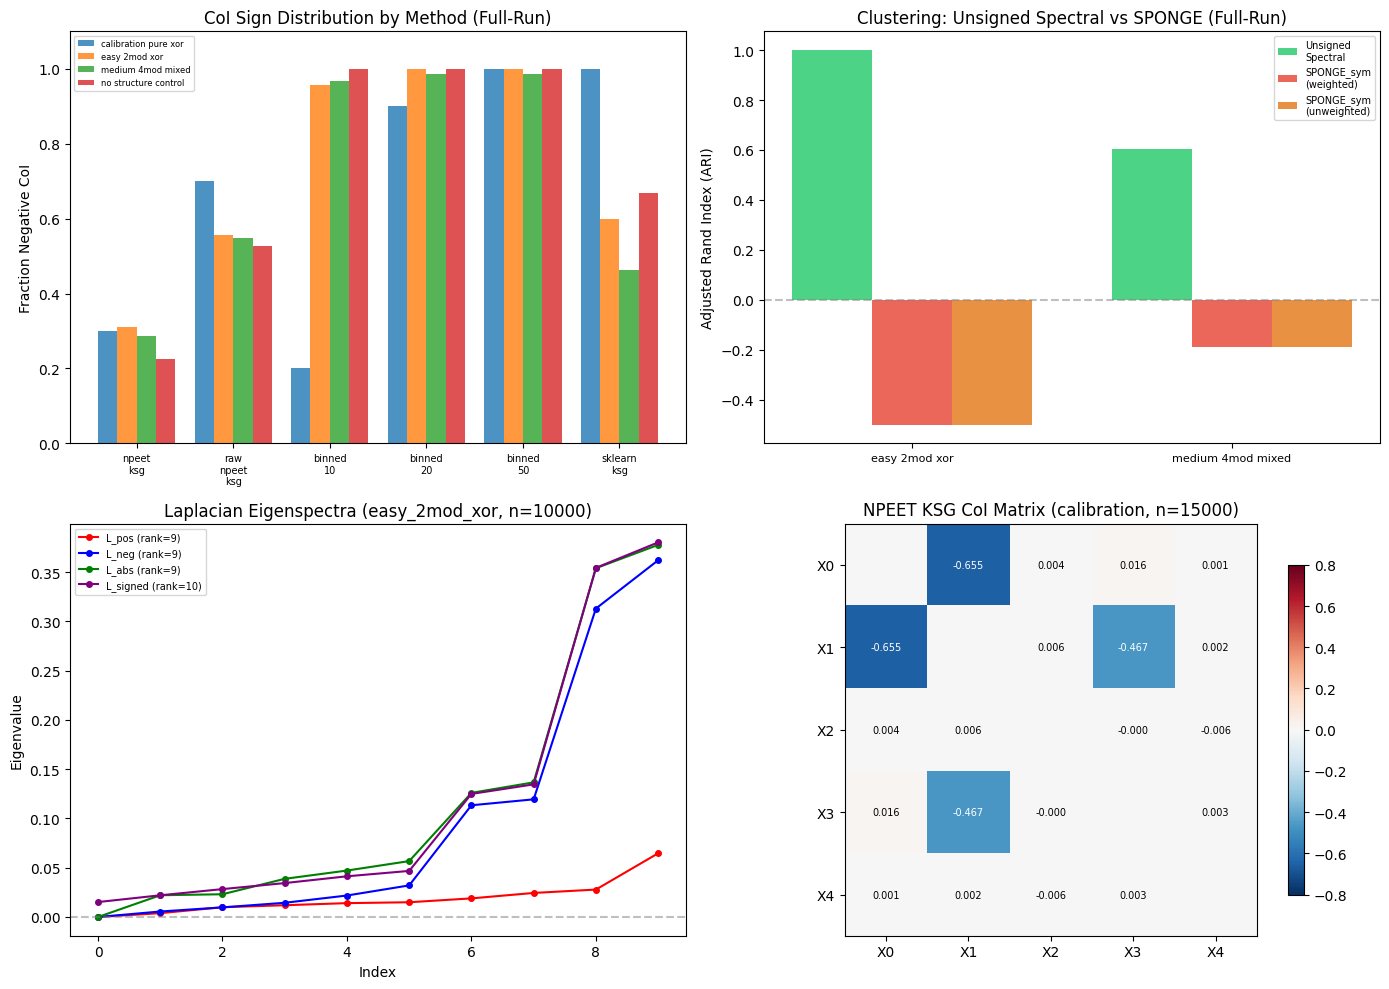


SUMMARY: Key Findings

All-negative CoI genuine? False
Explanation: Some AND-module redundant pairs show positive CoI with certain estimators, suggesting estimator bias partially explains the all-negative pattern.

SPONGE failure mechanism:
  When CoI is predominantly negative, A_pos ~= 0, so L_pos has rank ~0. SPONGE's B matrix (L_neg + tau*D_pos) degenerates to L_neg. The generalized eigenproblem becomes trivial (A~=0), yielding uninform...

Recommendations:
  1) Use unsigned spectral on |CoI| — discards signs but preserves magnitudes. 2) Center CoI by subtracting median to create artificial sign structure. 3) Consider partial correlation or conditional MI ...

--- Live Demo Results (n_samples=15000/10000) ---

  calibration_pure_xor:
    npeet_ksg: neg=0.3, pos=0.6, zero=0.1
    raw_npeet_ksg: neg=0.3, pos=0.6, zero=0.1
    binned_10: neg=0.9, pos=0.0, zero=0.1
    binned_20: neg=1.0, pos=0.0, zero=0.0
    binned_50: neg=1.0, pos=0.0, zero=0.0
    sklearn_ksg: neg=0.3, pos=0.5, zer

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: CoI sign distributions from precomputed full-run data ---
ax = axes[0, 0]
p1_pre = data.get("part1_estimator_bias", {})
methods_order = ["npeet_ksg", "raw_npeet_ksg", "binned_10", "binned_20", "binned_50", "sklearn_ksg"]
ds_names_pre = ["calibration_pure_xor", "easy_2mod_xor", "medium_4mod_mixed", "no_structure_control"]
# Collect frac_negative for each dataset/method
plot_data = {}
for ds in ds_names_pre:
    ds_data = p1_pre.get(ds, {})
    fracs = []
    labels = []
    for m in methods_order:
        sd = ds_data.get(m, {}).get("sign_distribution", {})
        if "frac_negative" in sd:
            fracs.append(sd["frac_negative"])
            labels.append(m.replace("_", "\n"))
    if fracs:
        plot_data[ds] = (labels, fracs)

x_pos = np.arange(len(methods_order))
width = 0.2
for i, ds in enumerate(ds_names_pre):
    if ds in plot_data:
        labels, fracs = plot_data[ds]
        ax.bar(x_pos[:len(fracs)] + i * width, fracs, width, label=ds.replace("_", " "), alpha=0.8)
ax.set_ylabel("Fraction Negative CoI")
ax.set_title("CoI Sign Distribution by Method (Full-Run)")
ax.set_xticks(x_pos + width * 1.5)
ax.set_xticklabels([m.replace("_", "\n") for m in methods_order], fontsize=7)
ax.legend(fontsize=6, loc="upper left")
ax.set_ylim(0, 1.1)

# --- Plot 2: Clustering ARI comparison from precomputed data ---
ax = axes[0, 1]
p2_pre = data.get("part2_sponge_diagnosis", {})
cluster_data = []
for ds in ["easy_2mod_xor", "medium_4mod_mixed"]:
    cl = p2_pre.get(ds, {}).get("clustering_comparison", {})
    cluster_data.append({
        "dataset": ds.replace("_", " "),
        "Unsigned\nSpectral": cl.get("unsigned_spectral_ari", 0),
        "SPONGE_sym\n(weighted)": cl.get("sponge_sym_weighted_ari", 0),
        "SPONGE_sym\n(unweighted)": cl.get("sponge_sym_unweighted_ari", 0),
    })

if cluster_data:
    x = np.arange(len(cluster_data))
    w = 0.25
    keys = ["Unsigned\nSpectral", "SPONGE_sym\n(weighted)", "SPONGE_sym\n(unweighted)"]
    colors = ["#2ecc71", "#e74c3c", "#e67e22"]
    for i, k in enumerate(keys):
        vals = [cd.get(k, 0) or 0 for cd in cluster_data]
        ax.bar(x + i * w, vals, w, label=k, color=colors[i], alpha=0.85)
    ax.set_xticks(x + w)
    ax.set_xticklabels([cd["dataset"] for cd in cluster_data], fontsize=8)
    ax.set_ylabel("Adjusted Rand Index (ARI)")
    ax.set_title("Clustering: Unsigned Spectral vs SPONGE (Full-Run)")
    ax.legend(fontsize=7)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# --- Plot 3: Eigenspectrum from live computation ---
ax = axes[1, 0]
if "easy_2mod_xor" in part2_results:
    eigen = part2_results["easy_2mod_xor"]["eigenspectrum"]
    for lap_name, color in [("L_pos", "red"), ("L_neg", "blue"), ("L_abs", "green"), ("L_signed", "purple")]:
        evals = eigen.get(lap_name, {}).get("eigenvalues", [])
        if evals:
            ax.plot(range(len(evals)), evals, 'o-', color=color, label=f"{lap_name} (rank={eigen[lap_name]['rank']})", markersize=4)
    ax.set_xlabel("Index")
    ax.set_ylabel("Eigenvalue")
    ax.set_title(f"Laplacian Eigenspectra (easy_2mod_xor, n={N_EASY_SAMPLES})")
    ax.legend(fontsize=7)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# --- Plot 4: CoI heatmap from live computation ---
ax = axes[1, 1]
coi_cal = coi_store["calibration_pure_xor"]["npeet_ksg"]
im = ax.imshow(coi_cal, cmap="RdBu_r", vmin=-0.8, vmax=0.8, aspect="equal")
ax.set_title(f"NPEET KSG CoI Matrix (calibration, n={N_CAL_SAMPLES})")
ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels([f"X{i}" for i in range(5)])
ax.set_yticklabels([f"X{i}" for i in range(5)])
plt.colorbar(im, ax=ax, shrink=0.8)
# Annotate values
for i in range(5):
    for j in range(5):
        if i != j:
            ax.text(j, i, f"{coi_cal[i,j]:.3f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(coi_cal[i,j]) > 0.4 else "black")

plt.tight_layout()
plt.savefig("results_visualization.png", dpi=100, bbox_inches="tight")
plt.show()

# --- Summary Table ---
print("\n" + "="*70)
print("SUMMARY: Key Findings")
print("="*70)

# From precomputed conclusions
conclusions = data.get("conclusions", {})
print(f"\nAll-negative CoI genuine? {conclusions.get('is_all_negative_genuine', 'N/A')}")
print(f"Explanation: {conclusions.get('explanation', 'N/A')}")
print(f"\nSPONGE failure mechanism:")
print(f"  {conclusions.get('sponge_failure_mechanism', 'N/A')[:200]}...")
print(f"\nRecommendations:")
print(f"  {conclusions.get('recommendations', 'N/A')}")

# Live results summary
print(f"\n--- Live Demo Results (n_samples={N_CAL_SAMPLES}/{N_EASY_SAMPLES}) ---")
for ds_name in ["calibration_pure_xor", "easy_2mod_xor"]:
    print(f"\n  {ds_name}:")
    for method, mdata in part1_results.get(ds_name, {}).items():
        sd = mdata.get("sign_distribution", {})
        if sd:
            print(f"    {method}: neg={sd.get('frac_negative','-')}, pos={sd.get('frac_positive','-')}, zero={sd.get('frac_near_zero','-')}")

if "easy_2mod_xor" in part2_results:
    cl = part2_results["easy_2mod_xor"].get("clustering_comparison", {})
    print(f"\n  Clustering (easy_2mod_xor):")
    print(f"    Unsigned spectral ARI: {cl.get('unsigned_spectral_ari', 'N/A')}")
    print(f"    SPONGE_sym weighted ARI: {cl.get('sponge_sym_weighted_ari', 'N/A')}")
    print(f"    SPONGE_sym unweighted ARI: {cl.get('sponge_sym_unweighted_ari', 'N/A')}")
    print(f"    Positive edge fraction: {part2_results['easy_2mod_xor']['eigenspectrum']['positive_edge_fraction']}")
    print(f"    L_pos rank: {part2_results['easy_2mod_xor']['eigenspectrum']['L_pos']['rank']}")